# Load the data file and explore the data, showing size, data descriptions, data distributions with boxplot, pairplots . . .

In [41]:
import pandas as pd

df = pd.read_csv('written-test-2023-01-09-exam-data.csv',names=['idx','Gender','F1','F2','F3','F4','F5','F6','F7','class'])
df

,idx,Gender,F1,F2,F3,F4,F5,F6,F7,class
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,2.0
1,1,M,0.350,0.265,0.090,NaN,0.0995,0.0485,0.0700,0.0
2,2,F,0.530,0.420,0.135,NaN,0.2565,0.1415,0.2100,1.0
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,1.0
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,0.0
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,NaN,1.0
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,1.0
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,1.0
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,1.0


In [42]:
df.info()
print('---------------------------------------------')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   idx     4177 non-null   int64  
 1   Gender  4177 non-null   str    
 2   F1      3997 non-null   float64
 3   F2      3976 non-null   float64
 4   F3      3987 non-null   float64
 5   F4      3990 non-null   float64
 6   F5      3983 non-null   float64
 7   F6      4002 non-null   float64
 8   F7      3990 non-null   float64
 9   class   4177 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 326.5 KB
---------------------------------------------


,idx,F1,F2,F3,F4,F5,F6,F7,class
count,4177.000000,3997.000000,3976.000000,3987.000000,3990.000000,3983.000000,4002.000000,3990.000000,4177.000000
mean,2088.000000,0.525330,0.408448,0.139669,0.830577,0.360681,0.180995,0.239796,0.861623
std,1205.940366,0.119569,0.098728,0.041988,0.490629,0.221100,0.109425,0.139765,0.762510
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,0.000000
25%,1044.000000,0.450000,0.350000,0.115000,0.444500,0.188000,0.094000,0.130000,0.000000
50%,2088.000000,0.545000,0.425000,0.140000,0.802250,0.339000,0.171500,0.235000,1.000000
75%,3132.000000,0.615000,0.480000,0.165000,1.154375,0.503250,0.253500,0.330000,1.000000
max,4176.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,3.000000


In [43]:
# This is not a time series task so the index is probably not required here 
df1 = df.dropna().drop(columns=['idx'])
df1

,Gender,F1,F2,F3,F4,F5,F6,F7,class
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,2.0
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,1.0
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,0.0
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.1200,0.0
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.3300,3.0
...,...,...,...,...,...,...,...,...,...
4169,M,0.520,0.385,0.165,0.7910,0.3750,0.1800,0.1815,1.0
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,1.0
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,1.0
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,1.0


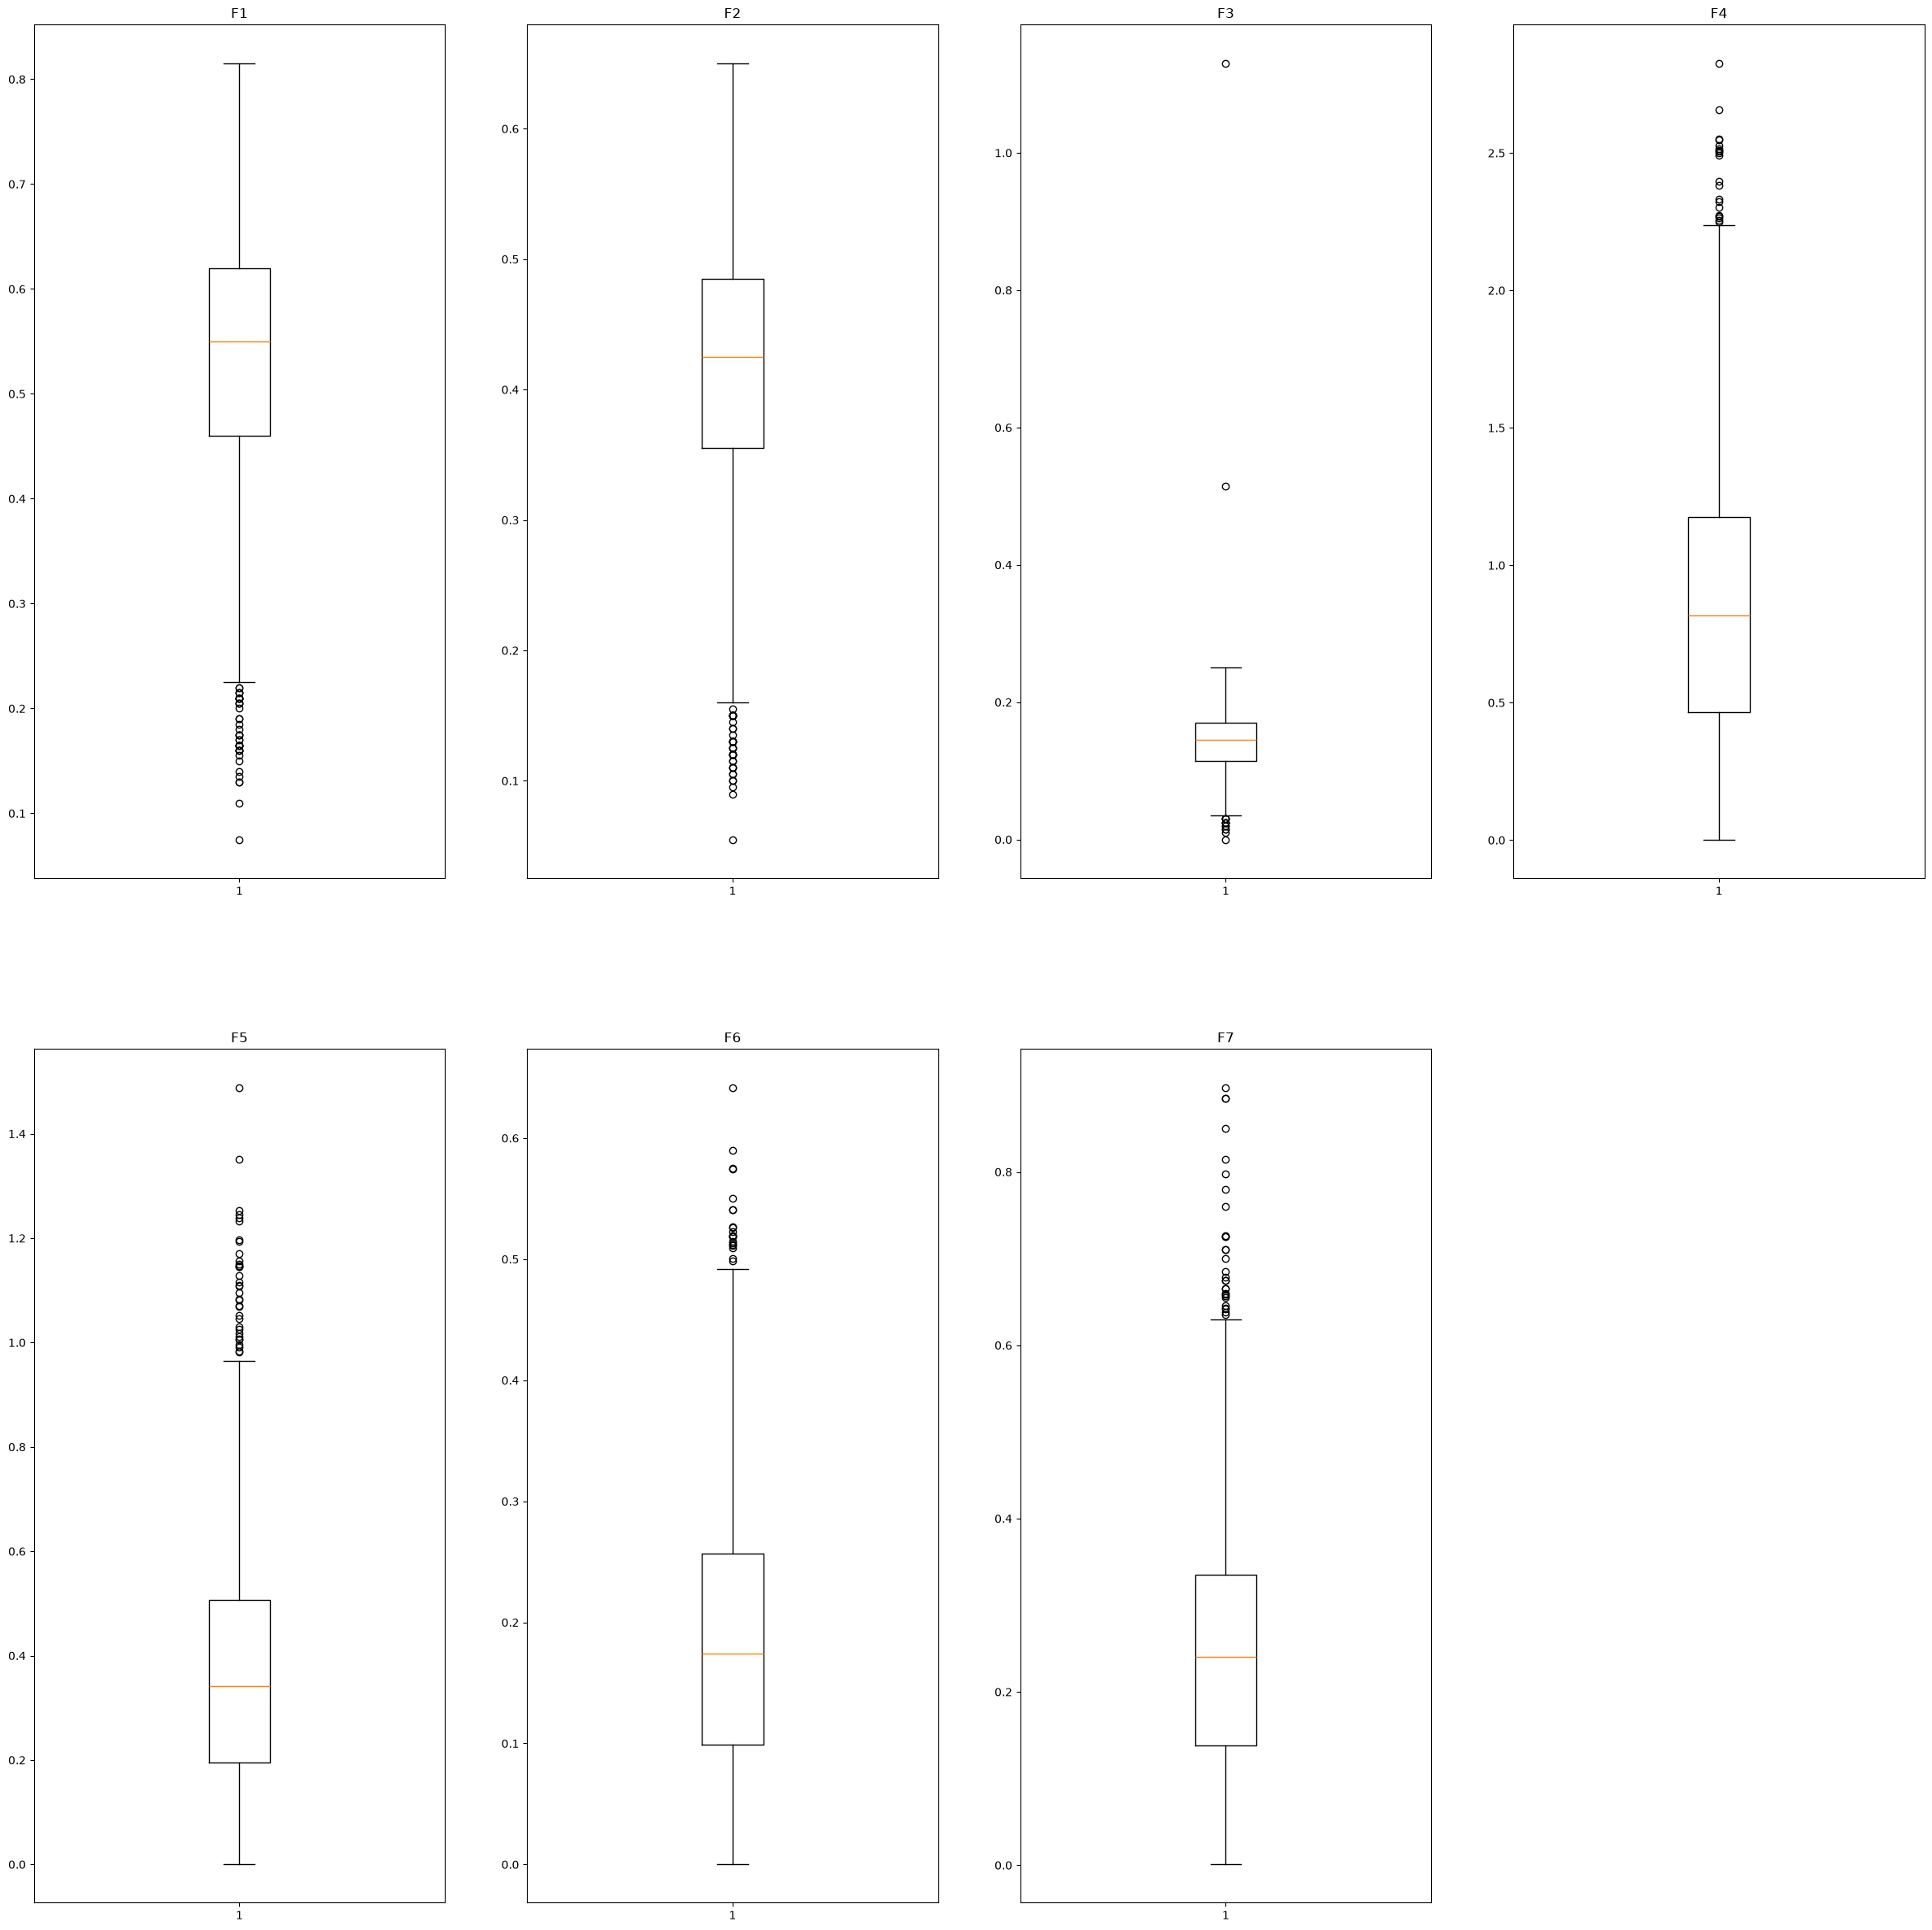

In [44]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(30,30))
for pos, col in enumerate(df1.columns[1:-1], start=1):
    plt.subplot(2, 4, pos)
    plt.boxplot(df1[col])
    plt.title(col)

plt.show()

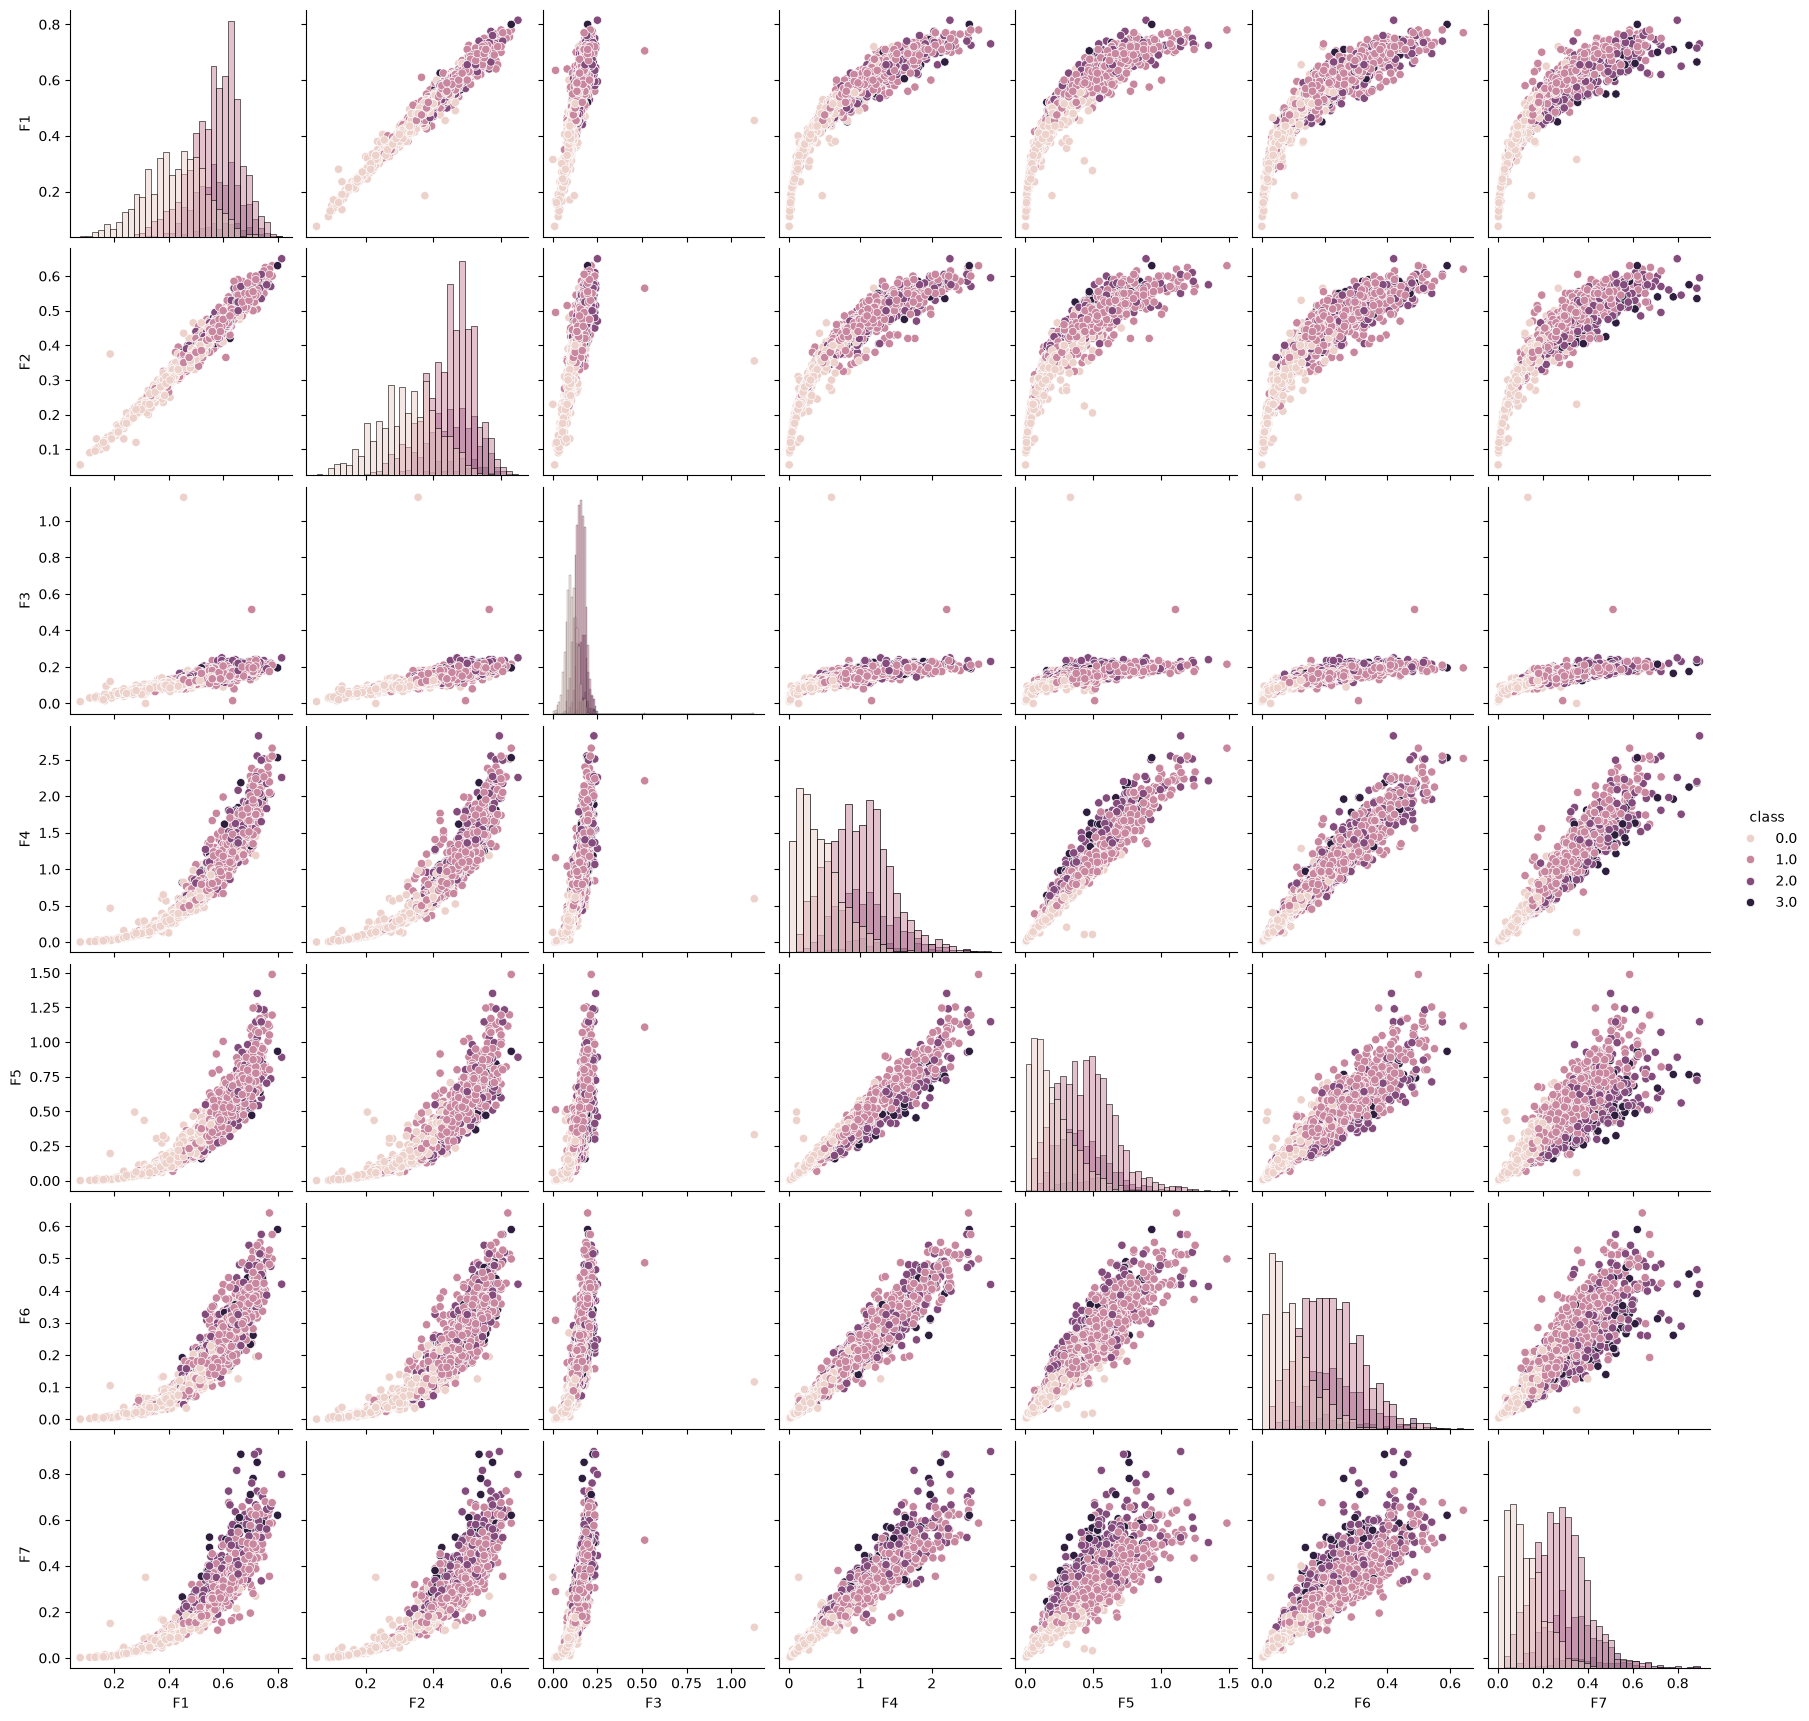

In [45]:
import seaborn as sns

sns.pairplot(df1, hue='class', diag_kind='hist')

# Comment the exploration of step 1 pointing out if there are imbalanced distributions, outliers, missing values . . .
# Drop the columns that are not relevant for the classification operation, if any, and explain why you do that. Deal with missing values, if any . . 
(both answered below)

The data had no header so they were added manually, the first column looked like and index (confirmed by the output of df.describe) but will probably not contribute or give any value to the model so it was dropped. The second column appears to be the gender which seems relavent since the data is about income. The rest apart from the last columns which is the label column, are features named FX.

Looking at the boxplot we first notice that the data needs to be normalized and the string values(gender column) must be one-hot encoded
F1 being sligthly left skewed and the outliers at the lower fence, F2 is also about the same, F3 values are at a much smaller range than the rest of the columns with outliers at the lower fence more than the upper fence but almost symmterical, F4,F5,F6,F7 are right skewed and have many ouliers on the upper fence. 

Finally from the pairplots we know that we have 4 classes where actually there could be an imbalance. Class 3 is barely visible on the histograms, and most entires are of classes 0 and 1. Choosing wether to drop them or not depends heavily on the application but imbalance can demonstrate the appearance of certian classes more than others due to it being the reality but if its an issue with the data collected then it can inriduce bias.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, OneHotEncoder

X = pd.get_dummies(df1.drop(columns=['Gender','class']))
y = df1['class']

X_norm = pd.DataFrame(normalize(X))

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.3, random_state=42)

# find the best classification scheme considering two classification methods, find the best hyperparameters using cross validation; the optimization must be focused on the f1_macro measure . 

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
random_state = 42
grid_dt = {'criterion':['gini', 'entropy', 'log_loss'],
           'max_features': ['sqrt', 'log2'],
           'max_depth': list(range(1,11))}

dt = DecisionTreeClassifier(class_weight='balanced',random_state=42)
gs_dt = GridSearchCV(dt, param_grid=grid_dt, scoring='f1_macro',cv=5)
gs_dt.fit(X_train,y_train)

print(f"Best score optained for DT: {gs_dt.best_score_:.2f} with paramters: {gs_dt.best_params_}")

Best score optained for DT: 0.49 with paramters: {'criterion': 'entropy', 'max_depth': 3, 'max_features': 'sqrt'}


In [48]:
from sklearn.ensemble import RandomForestClassifier

grid_rf = {'n_estimators': [50, 100, 200],
           'max_features': ['sqrt', 'log2'],
           'max_depth': list(range(1,11))}

rf = RandomForestClassifier(class_weight='balanced',random_state=42)
rf_dt = GridSearchCV(rf, param_grid=grid_rf, scoring='f1_macro',cv=5)
rf_dt.fit(X_train,y_train)

print(f"Best score optained for RF: {rf_dt.best_score_:.2f} with paramters: {rf_dt.best_params_}")

Best score optained for RF: 0.53 with paramters: {'max_depth': 9, 'max_features': 'sqrt', 'n_estimators': 200}


# Show the performance measures and the confusion matrices for the best hyperparameters of each model

In [49]:
dt_best = DecisionTreeClassifier(criterion='gini', max_depth=8, max_features='sqrt',random_state=42)
dt_best_fitted = dt_best.fit(X_train,y_train)

y_pred_dt_train = dt_best_fitted.predict(X_train)
y_pred_dt_test = dt_best_fitted.predict(X_test)

rf_best = RandomForestClassifier(n_estimators= 50 ,max_features='sqrt',max_depth=9 ,random_state=42)
rf_best_fitted = rf_best.fit(X_train,y_train)

y_pred_rf_train = rf_best_fitted.predict(X_train)
y_pred_rf_test = rf_best_fitted.predict(X_test)

In [50]:
from sklearn.metrics import classification_report

cr_dt_tr = classification_report(y_train,y_pred_dt_train)
cr_dt_tst = classification_report(y_test,y_pred_dt_test)
print('Decision Trees training results:')
print(cr_dt_tr)
print('------------------------------------------------------------------------')
print('Decision Trees testing results:')
print(cr_dt_tst)

Decision Trees training results:
              precision    recall  f1-score   support

         0.0       0.80      0.76      0.78       674
         1.0       0.71      0.84      0.77      1014
         2.0       0.68      0.52      0.59       385
         3.0       0.65      0.17      0.28        63

    accuracy                           0.73      2136
   macro avg       0.71      0.57      0.60      2136
weighted avg       0.73      0.73      0.73      2136

------------------------------------------------------------------------
Decision Trees testing results:
              precision    recall  f1-score   support

         0.0       0.70      0.75      0.73       270
         1.0       0.65      0.74      0.70       439
         2.0       0.53      0.37      0.43       172
         3.0       0.17      0.06      0.09        35

    accuracy                           0.65       916
   macro avg       0.51      0.48      0.48       916
weighted avg       0.63      0.65      0.63    

In [51]:
cr_rf_tr = classification_report(y_train,y_pred_rf_train)
cr_rf_tst = classification_report(y_test,y_pred_rf_test)
print('Random Forest training results:')
print(cr_rf_tr)
print('------------------------------------------------------------------------')
print('Random Forest testing results:')
print(cr_rf_tst)

Random Forest training results:
              precision    recall  f1-score   support

         0.0       0.94      0.84      0.88       674
         1.0       0.80      0.95      0.87      1014
         2.0       0.83      0.67      0.74       385
         3.0       1.00      0.35      0.52        63

    accuracy                           0.84      2136
   macro avg       0.89      0.70      0.75      2136
weighted avg       0.85      0.84      0.84      2136

------------------------------------------------------------------------
Random Forest testing results:
              precision    recall  f1-score   support

         0.0       0.77      0.75      0.76       270
         1.0       0.67      0.79      0.73       439
         2.0       0.55      0.39      0.46       172
         3.0       0.25      0.06      0.09        35

    accuracy                           0.68       916
   macro avg       0.56      0.50      0.51       916
weighted avg       0.66      0.68      0.66      

<Axes: >

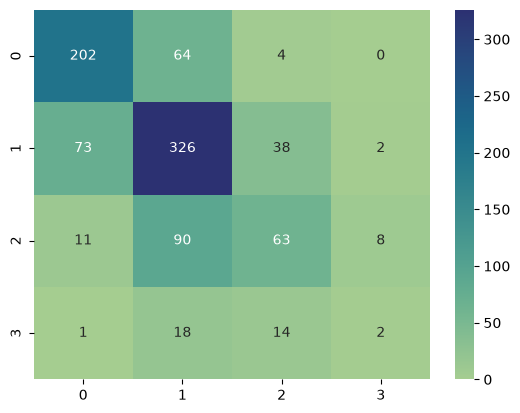

In [54]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, y_pred_dt_test)
sns.heatmap(dt_cm, annot=True,fmt='d',cmap="crest")

<Axes: >

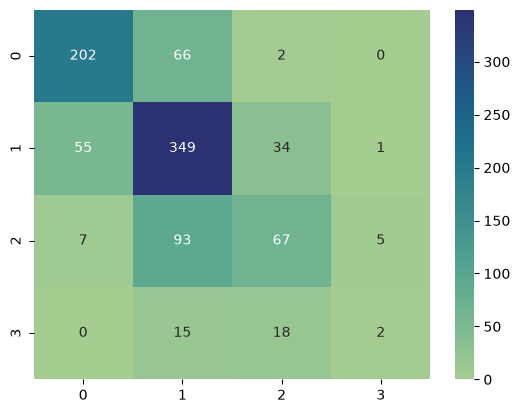

In [55]:
rf_cm = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(rf_cm,annot=True,fmt='d',cmap="crest")

# Comment the results . . .

DT achieved 48% f1 score, a training accuracy 73%, a testing accuracy of 65%. And RF achieved 53% f1 score, a training accuracy 84%, a testing accuracy of 68%. DT shows a ~10% capacity while RF shows ~20% which is even worse and both could indicate overfitting even though RF being an ensemble which reduces the variance due to averaging multiple trees instead of 1 in DT. This could be justified due to the unbalanced nature of the data and the confusion matrix confirms it by showing that the model gets correct testing predictions at the dominating classes 0 and 1 on both models. Perhaps using other balancing methods such as SMOTE would provide better results.